In [10]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant


def load_time_series(data):
    if "time_series" in data.files:
        return data["time_series"]
    if "time series" in data.files:
        return data["time series"]
    raise KeyError(f"No time-series key found in {data.files}")


def autocorr_to_spectrum(
    path,
    t_gaussian_fs=None,
    offset_ev=2.13,
    spectratype="abs",
    apply_prefactor=False,
):
    data = np.load(path)
    print(f"成功加载数据: {path}, 关联函数长度: {len(data['autocorr'])}")

    times_au = load_time_series(data)
    dt_au = times_au[1] - times_au[0]
    autocorr = np.asarray(data["autocorr"])
    t_axis = times_au - times_au[0]

    if t_gaussian_fs is None:
        broadening_filter = np.ones_like(t_axis, dtype=float)
    else:
        t_gaussian_au = t_gaussian_fs * constant.fs2au
        broadening_filter = np.exp(-(t_axis / t_gaussian_au) ** 2)
    c_t_broadened = autocorr * broadening_filter

    spectrum = np.fft.fft(c_t_broadened)
    fft_freqs_au = np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    offset_au = offset_ev * constant.ev2au

    if spectratype == "abs":
        freqs_au = offset_au - fft_freqs_au
    elif spectratype == "emi":
        freqs_au = offset_au + fft_freqs_au
    else:
        raise ValueError("spectratype should be 'abs' or 'emi'")

    freqs_cm = freqs_au * constant.au2cm
    intensities = np.abs(spectrum)
    if apply_prefactor:
        if spectratype == "abs":
            intensities *= freqs_au
        elif spectratype == "emi":
            intensities *= freqs_au ** 3

    positive_freq = freqs_cm > 0
    freqs_cm = freqs_cm[positive_freq]
    wavelength_nm = 1e7 / freqs_cm
    intensities = intensities[positive_freq]

    max_intensity = np.max(intensities)
    if max_intensity != 0:
        intensities = intensities / max_intensity

    idx_nm = np.argsort(wavelength_nm)
    idx_cm = np.argsort(freqs_cm)
    return {
        "wavelength_nm": wavelength_nm[idx_nm],
        "intensity_nm": intensities[idx_nm],
        "wavenumber_cm": freqs_cm[idx_cm],
        "intensity_cm": intensities[idx_cm],
    }


def plot_spectra_dual_axes(
    spectra_specs,
    spectratype,
    title,
    apply_prefactor=False,
    xlim_nm=None,
    xlim_cm=None,
    t_gaussian_fs=None,
    ylim=(-0.1, 1.1),
):
    if xlim_cm is None and xlim_nm is not None:
        xlim_cm = tuple(sorted((1e7 / xlim_nm[1], 1e7 / xlim_nm[0])))

    # fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # ax_nm, ax_cm = axes

    fig, axes = plt.subplots(1, 1, figsize=(8, 5))
    ax_nm = axes

    for spec in spectra_specs:
        result = autocorr_to_spectrum(
            path=spec["path"],
            t_gaussian_fs=t_gaussian_fs,
            offset_ev=spec["offset_ev"],
            spectratype=spectratype,
            apply_prefactor=apply_prefactor,
        )
        ax_nm.plot(
            result["wavelength_nm"],
            result["intensity_nm"],
            color=spec["color"],
            linestyle=spec.get("linestyle", "-"),
            linewidth=1.8,
            label=spec["label"],
        )
        # ax_cm.plot(
        #     result["wavenumber_cm"],
        #     result["intensity_cm"],
        #     color=spec["color"],
        #     linestyle=spec.get("linestyle", "-"),
        #     linewidth=1.8,
        #     label=spec["label"],
        # )

    if xlim_nm is not None:
        ax_nm.set_xlim(*xlim_nm)
    # if xlim_cm is not None:
    #     ax_cm.set_xlim(*xlim_cm)

    ax_nm.set_ylim(*ylim)
    # ax_cm.set_ylim(*ylim)

    ax_nm.set_title(f"{title} (nm)")
    # ax_cm.set_title(f"{title} (cm^-1)")
    ax_nm.set_xlabel("Wavelength (nm)", fontsize=16)
    # ax_cm.set_xlabel("Wavenumber (cm^-1)", fontsize=12)
    ax_nm.set_ylabel("Intensity (normalized)", fontsize=16)
    # ax_cm.set_ylabel("Intensity (normalized)", fontsize=12)
    ax_nm.grid(True, linestyle="--", alpha=0.7)
    # ax_cm.grid(True, linestyle="--", alpha=0.7)
    ax_nm.legend()
    # ax_cm.legend()
    plt.tight_layout()
    plt.show()


成功加载数据: ../singleset/pbi_dimer_ft_abs_42bd.npz, 关联函数长度: 5001
成功加载数据: ../singleset/pbi_dimer_ft_abs_120bd.npz, 关联函数长度: 5001
成功加载数据: ../multiset/pbi_dimer_ft_abs_multiset.npz, 关联函数长度: 5001


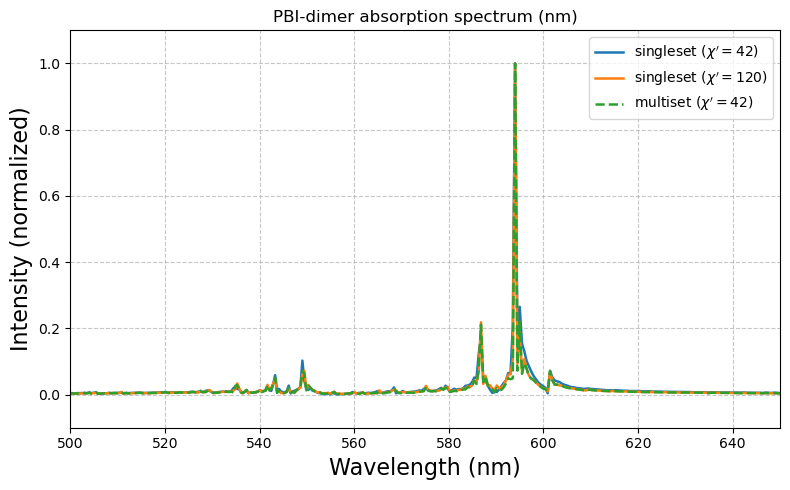

In [20]:
abs_specs = [
    {
        "path": "../singleset/pbi_dimer_ft_abs_42bd.npz",
        "label": "singleset ($\\chi'=42$)",
        "color": "#1f77b4",
        "linestyle": "-",
        "offset_ev": 2.13,
    },
    {
        "path": "../singleset/pbi_dimer_ft_abs_120bd.npz",
        "label": "singleset ($\\chi'=120$)",
        "color": "#ff7f0e",
        "linestyle": "-",
        "offset_ev": 2.13,
    },
    {
        "path": "../multiset/pbi_dimer_ft_abs_multiset.npz",
        "label": "multiset ($\\chi'=42$)",
        "color": "#2ca02c",
        "linestyle": "--",
        "offset_ev": 2.13,
    },
]

plot_spectra_dual_axes(
    spectra_specs=abs_specs,
    spectratype="abs",
    title="PBI-dimer absorption spectrum",
    apply_prefactor=True,
    xlim_nm=(500, 650),
)


成功加载数据: ../singleset/pbi_dimer_ft_abs_42bd.npz, 关联函数长度: 5001
成功加载数据: ../singleset/pbi_dimer_ft_abs_120bd.npz, 关联函数长度: 5001
成功加载数据: ../multiset/pbi_dimer_ft_abs_multiset.npz, 关联函数长度: 5001


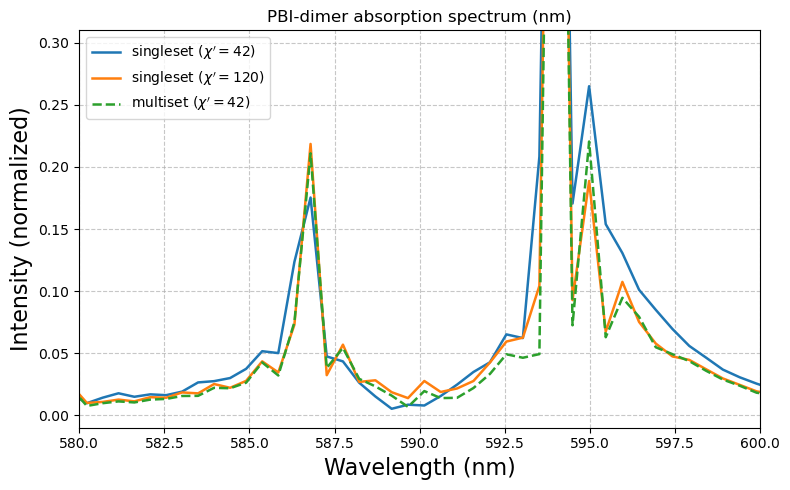

In [18]:
abs_specs = [
    {
        "path": "../singleset/pbi_dimer_ft_abs_42bd.npz",
        "label": "singleset ($\\chi'=42$)",
        "color": "#1f77b4",
        "linestyle": "-",
        "offset_ev": 2.13,
    },
    {
        "path": "../singleset/pbi_dimer_ft_abs_120bd.npz",
        "label": "singleset ($\\chi'=120$)",
        "color": "#ff7f0e",
        "linestyle": "-",
        "offset_ev": 2.13,
    },
    {
        "path": "../multiset/pbi_dimer_ft_abs_multiset.npz",
        "label": "multiset ($\\chi'=42$)",
        "color": "#2ca02c",
        "linestyle": "--",
        "offset_ev": 2.13,
    },
]

plot_spectra_dual_axes(
    spectra_specs=abs_specs,
    spectratype="abs",
    title="PBI-dimer absorption spectrum",
    apply_prefactor=True,
    xlim_nm=(580, 600),
    ylim=(-0.01,0.31)
)


成功加载数据: ../singleset/pbi_dimer_ft_emi_42bd.npz, 关联函数长度: 5001
成功加载数据: ../singleset/pbi_dimer_ft_emi_120bd.npz, 关联函数长度: 5001
成功加载数据: ../multiset/pbi_dimer_ft_emi_multiset.npz, 关联函数长度: 5001


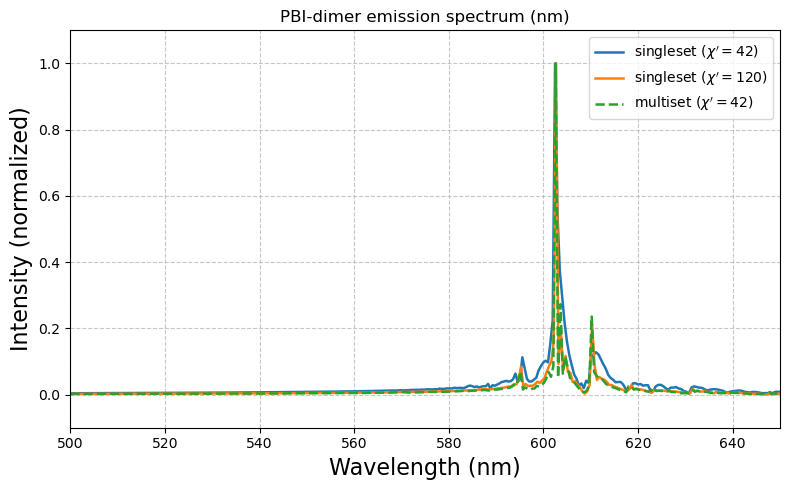

In [21]:
emi_specs = [
    {
        "path": "../singleset/pbi_dimer_ft_emi_42bd.npz",
        "label": "singleset ($\\chi'=42$)",
        "color": "#1f77b4",
        "linestyle": "-",
        "offset_ev": 2.13-0.001 - 0.03, #2.13-0.001
    },
    {
        "path": "../singleset/pbi_dimer_ft_emi_120bd.npz",
        "label": "singleset ($\\chi'=120$)",
        "color": "#ff7f0e",
        "linestyle": "-",
        "offset_ev": 2.13 - 0.03, #2.13
    },
    {
        "path": "../multiset/pbi_dimer_ft_emi_multiset.npz",
        "label": "multiset ($\\chi'=42$)",
        "color": "#2ca02c",
        "linestyle": "--",
        "offset_ev": 2.13+0.043 - 0.03,#2.13+0.043
    },
    # {
    #     "path": "/curie-home/zengjj/Renormalizer/multiset_202605/pbi_ft_ancilla/multiset/pbi_dimer_ft_ancilla_emi_multiset.npz",
    #     "label": "multiset-chi42",
    #     "color": "#ed3b3b",
    #     "linestyle": "--",
    #     "offset_ev": 2.13+0.043, # 2.13+0.043
    # },
]

plot_spectra_dual_axes(
    spectra_specs=emi_specs,
    spectratype="emi",
    title="PBI-dimer emission spectrum",
    apply_prefactor=False,
    xlim_nm=(500, 650),
)


成功加载数据: ../singleset/pbi_dimer_ft_emi_42bd.npz, 关联函数长度: 5001
成功加载数据: ../singleset/pbi_dimer_ft_emi_120bd.npz, 关联函数长度: 5001
成功加载数据: ../multiset/pbi_dimer_ft_emi_multiset.npz, 关联函数长度: 5001


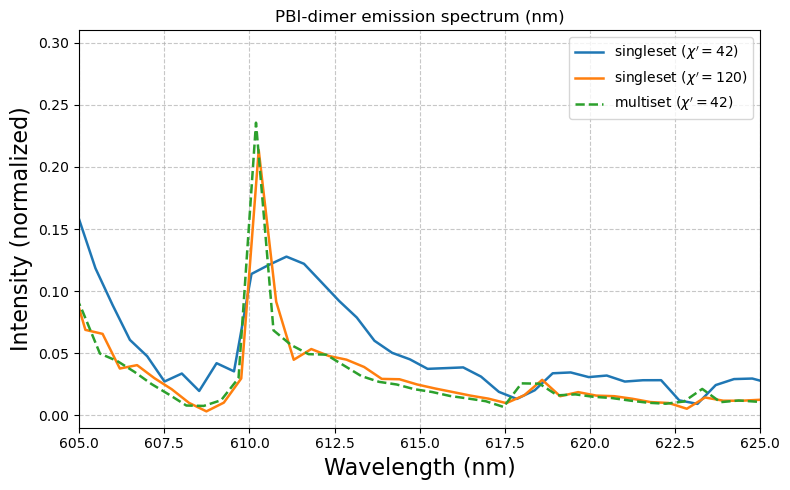

In [ ]:
emi_specs = [
    {
        "path": "../singleset/pbi_dimer_ft_emi_42bd.npz",
        "label": "singleset ($\\chi'=42$)",
        "color": "#1f77b4",
        "linestyle": "-",
        "offset_ev": 2.13-0.001 - 0.03, #2.13-0.001
    },
    {
        "path": "../singleset/pbi_dimer_ft_emi_120bd.npz",
        "label": "singleset ($\\chi'=120$)",
        "color": "#ff7f0e",
        "linestyle": "-",
        "offset_ev": 2.13 - 0.03, #2.13
    },
    {
        "path": "../multiset/pbi_dimer_ft_emi_multiset.npz",
        "label": "multiset ($\\chi'=42$)",
        "color": "#2ca02c",
        "linestyle": "--",
        "offset_ev": 2.13+0.043 - 0.03,#2.13+0.043
    },
    # {
    #     "path": "/curie-home/zengjj/Renormalizer/multiset_202605/pbi_ft_ancilla/multiset/pbi_dimer_ft_ancilla_emi_multiset.npz",
    #     "label": "multiset-chi42",
    #     "color": "#ed3b3b",
    #     "linestyle": "--",
    #     "offset_ev": 2.13+0.043, # 2.13+0.043
    # },
]

plot_spectra_dual_axes(
    spectra_specs=emi_specs,
    spectratype="emi",
    title="PBI-dimer emission spectrum",
    apply_prefactor=False,
    xlim_nm=(602.5, 622.5),
    ylim=(-0.01,0.31)
)
